# Stage 2 Analysis Dashboard

This notebook loads saved Stage 2 experiment outputs and provides a standardized analysis
layer for method comparison, support-size comparison, inner-step comparison,
repeated-episode stability inspection, prediction distribution diagnostics,
and thesis-ready result tables.

All plots use the shared DTU-aligned plotting utilities from `master_thesis.plotting`.
This notebook does not re-run any experiments; it analyzes saved outputs only.


In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from master_thesis.plotting import (
    set_thesis_style,
    plot_stage2_metric_comparison,
    plot_repeated_episode_boxplot,
    plot_inner_step_curve,
    plot_prediction_probability_distribution,
    plot_support_size_curve,
    plot_meta_training_curve,
    plot_collapse_rate,
    plot_episode_prediction_stats,
    plot_department_embedding_projection,
    plot_gold_label_embedding_projection,
    plot_pre_post_adaptation_projection,
    plot_embedding_shift_magnitude,
    plot_shap_summary_bar,
    plot_shap_local_bar,
    plot_shap_delta_importance,
    plot_view_level_shap_importance,
    plot_method_comparison_bars,
    plot_lr_sweep_comparison,
    plot_collapse_rate_heatmap,
)

set_thesis_style(palette="dtu", font_scale=1.05, grid=False)

EXPERIMENT_ROOT = PROJECT_ROOT / "models" / "stage_2" / "experiments"
SUMMARY_PATH = EXPERIMENT_ROOT / "experiment_summary.csv"
REPORTS_DIR = PROJECT_ROOT / "reports" / "stage2"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)


## Load Experiment Registry


In [2]:
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f"Experiment summary not found: {SUMMARY_PATH}")

summary_df = pd.read_csv(SUMMARY_PATH)
print("Loaded experiment summary:", SUMMARY_PATH)
print("Rows:", len(summary_df))
print("Methods:", summary_df["method"].unique().tolist() if "method" in summary_df.columns else "N/A")
display(summary_df.head(20))


Loaded experiment summary: /Users/Thomas/Desktop/Master Thesis/models/stage_2/experiments/experiment_summary.csv
Rows: 15
Methods: ['anil', 'finetune', 'fomaml', 'maml', 'zero_shot']


,experiment_id,method,init_name,target_department,n_support_pos,n_support_neg,inner_steps,status,gold_auroc_mean,gold_auroc_std,...,ndcg_at_20_std,n_metric_rows,n_predictions,n_episodes_diagnosed,collapse_rate,pred_mean_mean,pred_std_mean,frac_near_zero_mean,frac_near_one_mean,was_skipped
0,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,1,success,0.414242,0.173365,...,0.176688,20,821,20,0.00,0.499507,0.111889,0.000000,0.00200,False
1,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,3,success,0.520538,0.202176,...,0.211562,20,821,20,0.00,0.504030,0.097584,0.000000,0.00000,False
2,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,5,success,0.541822,0.201233,...,0.219626,20,821,20,0.00,0.504069,0.097777,0.000000,0.00000,False
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,1,success,0.503264,0.033126,...,0.087734,20,821,20,0.90,0.479794,0.027914,0.505691,0.44628,False
4,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,3,success,0.503264,0.033126,...,0.087734,20,821,20,0.90,0.479794,0.027914,0.505691,0.44628,False
5,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,5,success,0.503264,0.033126,...,0.087734,20,821,20,0.90,0.479794,0.027914,0.505691,0.44628,False
6,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,1,success,0.477725,0.090633,...,0.097781,20,821,20,1.00,0.479683,0.002571,0.100000,0.00000,False
7,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,3,success,0.489912,0.025362,...,0.087382,20,821,20,1.00,0.595514,0.002679,0.000000,0.00000,False
8,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,5,success,0.502540,0.031930,...,0.084676,20,821,20,1.00,0.596908,0.002152,0.000000,0.00000,False
9,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,A_weak_only,Logistics,2,2,1,success,0.467607,0.193761,...,0.135179,20,821,20,0.80,0.641213,0.007785,0.150000,0.34750,False


## Dashboard Filters

Edit the variables below to filter the experiments shown in all subsequent cells.
Set any filter to `None` to include all values.


In [3]:
SELECTED_TARGET_DEPARTMENT = "Logistics"
METHOD_FILTER = None              # e.g. ["anil", "finetune"]
INIT_FILTER = None                # e.g. ["A_weak_only"]
SUPPORT_FILTER = None             # e.g. (2, 2) for n_support_pos=2, n_support_neg=2
INNER_STEPS_FILTER = None         # e.g. [3, 5]
SELECTED_EXPERIMENT_ID = None     # e.g. "stage2__init-A_weak_only__method-anil__kpos-2__kneg-2__steps-3__target-Logistics"


In [4]:
filtered_df = summary_df.copy()

if "target_department" in filtered_df.columns and SELECTED_TARGET_DEPARTMENT is not None:
    filtered_df = filtered_df[filtered_df["target_department"] == SELECTED_TARGET_DEPARTMENT].copy()
if METHOD_FILTER is not None and "method" in filtered_df.columns:
    filtered_df = filtered_df[filtered_df["method"].isin(METHOD_FILTER)].copy()
if INIT_FILTER is not None and "init_name" in filtered_df.columns:
    filtered_df = filtered_df[filtered_df["init_name"].isin(INIT_FILTER)].copy()
if SUPPORT_FILTER is not None and {"n_support_pos", "n_support_neg"}.issubset(filtered_df.columns):
    filtered_df = filtered_df[
        (filtered_df["n_support_pos"] == SUPPORT_FILTER[0]) &
        (filtered_df["n_support_neg"] == SUPPORT_FILTER[1])
    ].copy()
if INNER_STEPS_FILTER is not None and "inner_steps" in filtered_df.columns:
    filtered_df = filtered_df[filtered_df["inner_steps"].isin(INNER_STEPS_FILTER)].copy()

print("Filtered rows:", len(filtered_df))
display(filtered_df.head(20))


Filtered rows: 15


,experiment_id,method,init_name,target_department,n_support_pos,n_support_neg,inner_steps,status,gold_auroc_mean,gold_auroc_std,...,ndcg_at_20_std,n_metric_rows,n_predictions,n_episodes_diagnosed,collapse_rate,pred_mean_mean,pred_std_mean,frac_near_zero_mean,frac_near_one_mean,was_skipped
0,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,1,success,0.414242,0.173365,...,0.176688,20,821,20,0.00,0.499507,0.111889,0.000000,0.00200,False
1,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,3,success,0.520538,0.202176,...,0.211562,20,821,20,0.00,0.504030,0.097584,0.000000,0.00000,False
2,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,5,success,0.541822,0.201233,...,0.219626,20,821,20,0.00,0.504069,0.097777,0.000000,0.00000,False
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,1,success,0.503264,0.033126,...,0.087734,20,821,20,0.90,0.479794,0.027914,0.505691,0.44628,False
4,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,3,success,0.503264,0.033126,...,0.087734,20,821,20,0.90,0.479794,0.027914,0.505691,0.44628,False
5,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,5,success,0.503264,0.033126,...,0.087734,20,821,20,0.90,0.479794,0.027914,0.505691,0.44628,False
6,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,1,success,0.477725,0.090633,...,0.097781,20,821,20,1.00,0.479683,0.002571,0.100000,0.00000,False
7,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,3,success,0.489912,0.025362,...,0.087382,20,821,20,1.00,0.595514,0.002679,0.000000,0.00000,False
8,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,5,success,0.502540,0.031930,...,0.084676,20,821,20,1.00,0.596908,0.002152,0.000000,0.00000,False
9,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,A_weak_only,Logistics,2,2,1,success,0.467607,0.193761,...,0.135179,20,821,20,0.80,0.641213,0.007785,0.150000,0.34750,False


## Method Comparison


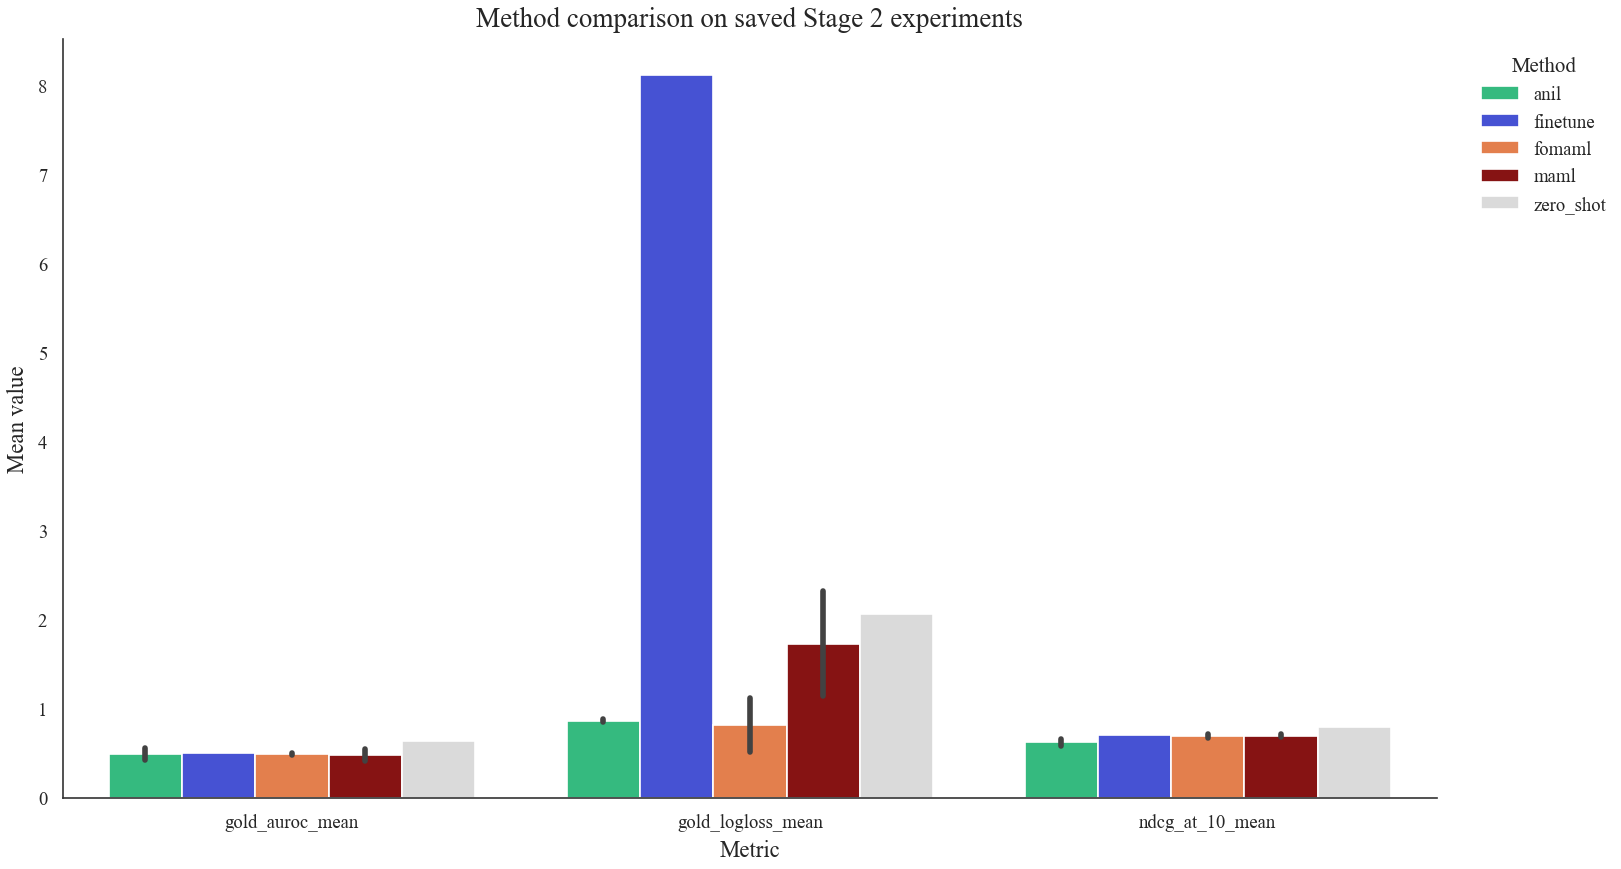

In [5]:
metric_columns = [
    c for c in ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean"] if c in filtered_df.columns
]
if not filtered_df.empty and metric_columns and "method" in filtered_df.columns:
    fig, ax = plot_stage2_metric_comparison(
        filtered_df,
        metrics=metric_columns,
        group_col="method",
        title="Method comparison on saved Stage 2 experiments",
    )
else:
    print("Method comparison plot could not be produced from the current filtered registry.")


## Support-Size Comparison


In [6]:
if not filtered_df.empty and {"n_support_pos", "n_support_neg"}.issubset(filtered_df.columns):
    support_df = filtered_df.copy()
    support_df["support_label"] = (
        support_df["n_support_pos"].astype(str) + "/" + support_df["n_support_neg"].astype(str)
    )
    metric_columns_s = [
        c for c in ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean"] if c in support_df.columns
    ]
    if metric_columns_s and len(support_df["support_label"].unique()) > 1:
        fig, ax = plot_stage2_metric_comparison(
            support_df,
            metrics=metric_columns_s,
            group_col="support_label",
            title="Support-size comparison",
        )
    else:
        print("Support-size comparison skipped: fewer than 2 distinct support configurations.")


Support-size comparison skipped: fewer than 2 distinct support configurations.


## Inner-Step Adaptation Curve


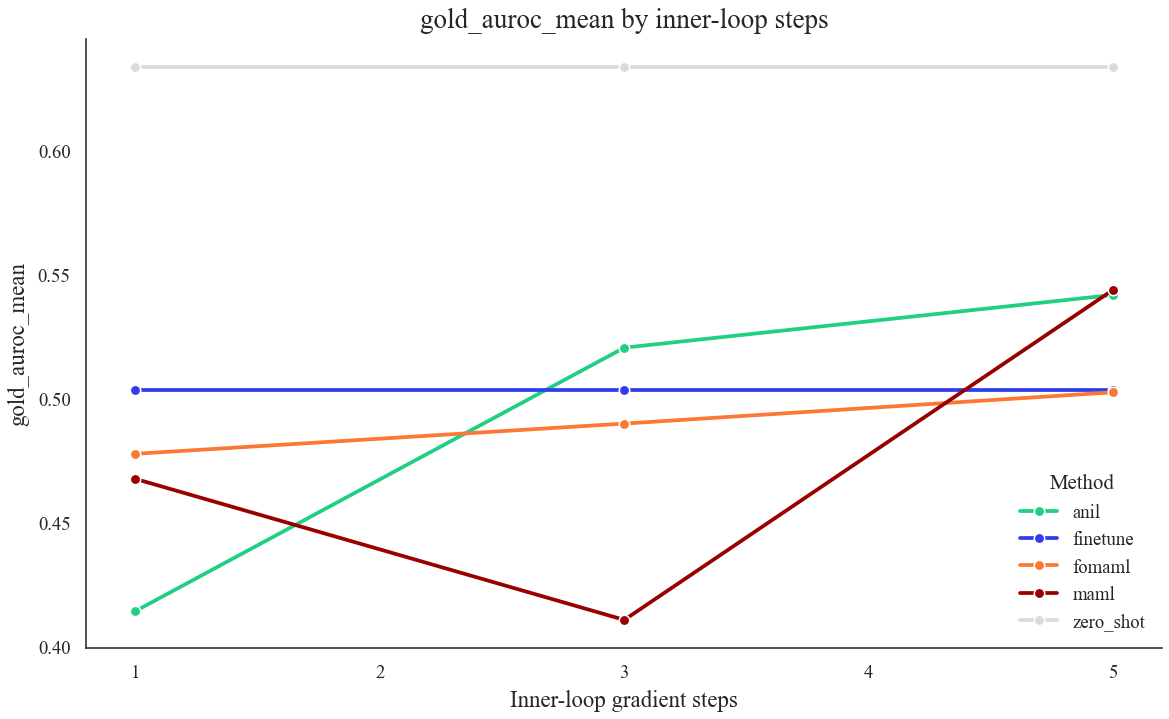

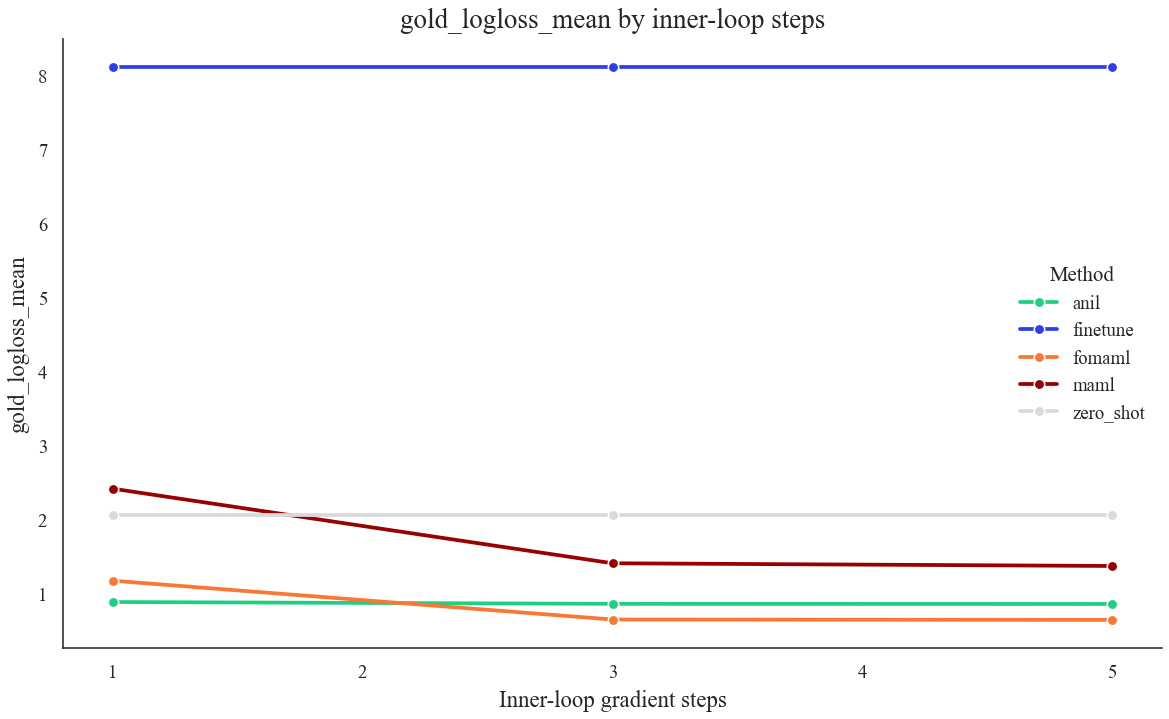

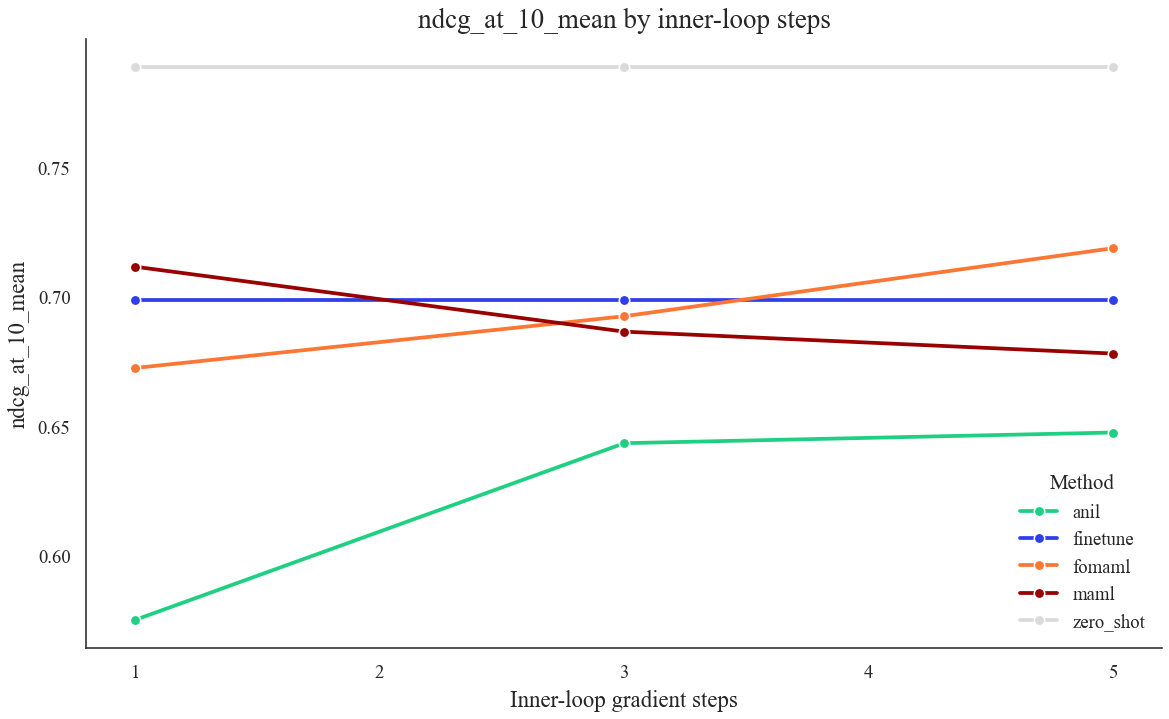

In [7]:
if not filtered_df.empty and "inner_steps" in filtered_df.columns:
    _has_method = "method" in filtered_df.columns
    _step_values = filtered_df["inner_steps"].unique()
    for _metric_col in [
        c for c in ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean"] if c in filtered_df.columns
    ]:
        if len(_step_values) > 1:
            _kwargs = dict(
                metric_col=_metric_col,
                step_col="inner_steps",
                title=f"{_metric_col} by inner-loop steps",
            )
            if _has_method:
                _kwargs["method_col"] = "method"
            fig, ax = plot_inner_step_curve(filtered_df, **_kwargs)
        else:
            print(f"Inner-step curve skipped for {_metric_col}: only one inner_steps value.")


## Initialization Ablation


In [8]:
if not filtered_df.empty and "init_name" in filtered_df.columns:
    metric_columns_i = [
        c for c in ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean"] if c in filtered_df.columns
    ]
    if metric_columns_i and len(filtered_df["init_name"].unique()) > 1:
        fig, ax = plot_stage2_metric_comparison(
            filtered_df,
            metrics=metric_columns_i,
            group_col="init_name",
            title="Initialization ablation",
        )
    else:
        print("Initialization ablation skipped: fewer than 2 distinct init_name values.")


Initialization ablation skipped: fewer than 2 distinct init_name values.


## Per-Experiment Artifact Inspection

Set `SELECTED_EXPERIMENT_ID` in the filters cell to load and inspect a specific experiment's artifacts.


In [9]:
def load_experiment_artifacts(experiment_id: str) -> dict:
    exp_dir = EXPERIMENT_ROOT / experiment_id
    artifacts = {
        "metrics": pd.DataFrame(),
        "predictions": pd.DataFrame(),
        "history": pd.DataFrame(),
    }
    for key, filename in [("metrics", "metrics.csv"), ("predictions", "predictions.csv"), ("history", "history.csv")]:
        path = exp_dir / filename
        if path.exists():
            artifacts[key] = pd.read_csv(path)
    return artifacts


if SELECTED_EXPERIMENT_ID is not None:
    artifacts = load_experiment_artifacts(SELECTED_EXPERIMENT_ID)
    metrics_df = artifacts["metrics"]
    preds_df = artifacts["predictions"]
    history_df = artifacts["history"]

    print("metrics.csv rows:", len(metrics_df))
    display(metrics_df.head() if not metrics_df.empty else metrics_df)
    print("predictions.csv rows:", len(preds_df))
    display(preds_df.head() if not preds_df.empty else preds_df)
    print("history.csv rows:", len(history_df))
    display(history_df.head() if not history_df.empty else history_df)

    # Repeated-episode stability: one plot per metric
    if not metrics_df.empty:
        metric_candidates = [c for c in ["gold_auroc", "gold_logloss", "ndcg_at_10"] if c in metrics_df.columns]
        for _m in metric_candidates:
            fig, ax = plot_repeated_episode_boxplot(
                metrics_df,
                metric_col=_m,
                title=f"Repeated-episode stability ({_m}): {SELECTED_EXPERIMENT_ID}",
            )

    # Prediction probability distribution
    if not preds_df.empty:
        prob_cols = [c for c in ["y_prob", "pred_prob", "probability", "y_pred_prob"] if c in preds_df.columns]
        if prob_cols:
            fig, ax = plot_prediction_probability_distribution(
                preds_df,
                prob_col=prob_cols[0],
                method_col=None,  # single-experiment view
                title=f"Prediction distribution: {SELECTED_EXPERIMENT_ID}",
            )
else:
    print("Set SELECTED_EXPERIMENT_ID in the filters cell to inspect a saved experiment in detail.")


Set SELECTED_EXPERIMENT_ID in the filters cell to inspect a saved experiment in detail.


---
## Thesis-Ready Result Tables

The tables below are formatted for direct use as the basis for thesis tables.
Tables are also saved as CSV files in `reports/stage2/`.

| Table | Purpose |
|-------|---|
| D | Main Stage 2 benchmark: method × init × support × inner_steps |
| E | Adaptation dynamics: grouped by inner_steps |
| F | Support-size sensitivity: grouped by n_support_pos/n_support_neg |
| G | Initialization ablation: grouped by init_name |
| H | Best-run leaderboard: one row per experiment, sorted by primary metric |
| I | Stage 1 vs Stage 2 comparison for the target department |


In [10]:
# Helper: canonical metric column display names
_METRIC_RENAME = {
    "gold_auroc_mean": "AUROC mean",
    "gold_auroc_std": "AUROC std",
    "gold_logloss_mean": "Log-Loss mean",
    "gold_logloss_std": "Log-Loss std",
    "ndcg_at_10_mean": "NDCG@10 mean",
    "ndcg_at_10_std": "NDCG@10 std",
    "gold_ece_mean": "ECE mean",
    "gold_ece_std": "ECE std",
    "precision_at_10_mean": "P@10 mean",
    "precision_at_10_std": "P@10 std",
}

_MEAN_COLS = ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean", "gold_ece_mean", "precision_at_10_mean"]
_STD_COLS = ["gold_auroc_std", "gold_logloss_std", "ndcg_at_10_std", "gold_ece_std", "precision_at_10_std"]

def _available(cols, df):
    return [c for c in cols if c in df.columns]

def _format_table(df, rename=True):
    df = df.copy()
    if rename:
        df = df.rename(columns={k: v for k, v in _METRIC_RENAME.items() if k in df.columns})
    for c in df.select_dtypes(include="float").columns:
        df[c] = df[c].round(4)
    return df.reset_index(drop=True)


### Table D: Main Stage 2 Benchmark

Primary comparison of all methods. Rows correspond to unique (method, init_name, support, inner_steps) combinations.


In [11]:
_id_cols_d = [c for c in ["method", "init_name", "n_support_pos", "n_support_neg", "inner_steps",
                             "target_department", "status", "n_metric_rows"] if c in summary_df.columns]
_metric_cols_d = _available(_MEAN_COLS + _STD_COLS, summary_df)
_cols_d = _id_cols_d + _metric_cols_d

_sort_d = [c for c in ["method", "init_name", "n_support_pos", "inner_steps"] if c in _cols_d]

table_d = summary_df[_cols_d].sort_values(_sort_d).reset_index(drop=True)
table_d_display = _format_table(table_d)
display(table_d_display)

table_d.to_csv(REPORTS_DIR / "table_D_stage2_main_benchmark.csv", index=False)
print("Saved:", REPORTS_DIR / "table_D_stage2_main_benchmark.csv")


,method,init_name,n_support_pos,n_support_neg,inner_steps,target_department,status,n_metric_rows,AUROC mean,Log-Loss mean,NDCG@10 mean,ECE mean,P@10 mean,AUROC std,Log-Loss std,NDCG@10 std,ECE std,P@10 std
0,anil,A_weak_only,2,2,1,Logistics,success,20,0.4142,0.8810,0.5751,0.3471,0.565,0.1734,0.2426,0.2866,0.1310,0.2780
1,anil,A_weak_only,2,2,3,Logistics,success,20,0.5205,0.8565,0.6434,0.3372,0.635,0.2022,0.2192,0.3414,0.1417,0.3410
2,anil,A_weak_only,2,2,5,Logistics,success,20,0.5418,0.8546,0.6475,0.3336,0.635,0.2012,0.2159,0.3460,0.1377,0.3454
3,finetune,A_weak_only,2,2,1,Logistics,success,20,0.5033,8.1115,0.6989,0.4671,0.675,0.0331,4.2650,0.1138,0.2044,0.3284
4,finetune,A_weak_only,2,2,3,Logistics,success,20,0.5033,8.1115,0.6989,0.4671,0.675,0.0331,4.2650,0.1138,0.2044,0.3284
5,finetune,A_weak_only,2,2,5,Logistics,success,20,0.5033,8.1115,0.6989,0.4671,0.675,0.0331,4.2650,0.1138,0.2044,0.3284
6,fomaml,A_weak_only,2,2,1,Logistics,success,20,0.4777,1.1693,0.6724,0.2195,0.655,0.0906,1.4844,0.1385,0.2044,0.3122
7,fomaml,A_weak_only,2,2,3,Logistics,success,20,0.4899,0.6444,0.6924,0.1226,0.690,0.0254,0.0279,0.0874,0.0810,0.3223
8,fomaml,A_weak_only,2,2,5,Logistics,success,20,0.5025,0.6394,0.7187,0.1147,0.715,0.0319,0.0283,0.0864,0.0756,0.3151
9,maml,A_weak_only,2,2,1,Logistics,success,20,0.4676,2.4123,0.7116,0.3503,0.685,0.1938,2.5877,0.1626,0.2145,0.2495


Saved: /Users/Thomas/Desktop/Master Thesis/reports/stage2/table_D_stage2_main_benchmark.csv


### Table E: Adaptation Dynamics by Inner Steps

Group by inner_steps to show how adaptation depth affects performance.


In [12]:
if "inner_steps" in summary_df.columns:
    _agg_e = {c: ["mean", "std"] for c in _available(_MEAN_COLS, summary_df)}
    if _agg_e:
        _group_e = [c for c in ["inner_steps", "method"] if c in summary_df.columns]
        table_e = summary_df.groupby(_group_e)[_available(_MEAN_COLS, summary_df)].agg(["mean", "std"])
        table_e.columns = ["_".join(c) for c in table_e.columns]
        table_e = table_e.reset_index().round(4)
        display(table_e)
        table_e.to_csv(REPORTS_DIR / "table_E_stage2_adaptation_dynamics.csv", index=False)
        print("Saved:", REPORTS_DIR / "table_E_stage2_adaptation_dynamics.csv")
    else:
        print("No mean metric columns available for Table E.")
else:
    print("inner_steps column not found in summary.")


,inner_steps,method,gold_auroc_mean_mean,gold_auroc_mean_std,gold_logloss_mean_mean,gold_logloss_mean_std,ndcg_at_10_mean_mean,ndcg_at_10_mean_std,gold_ece_mean_mean,gold_ece_mean_std,precision_at_10_mean_mean,precision_at_10_mean_std
0,1,anil,0.4142,NaN,0.8810,NaN,0.5751,NaN,0.3471,NaN,0.565,NaN
1,1,finetune,0.5033,NaN,8.1115,NaN,0.6989,NaN,0.4671,NaN,0.675,NaN
2,1,fomaml,0.4777,NaN,1.1693,NaN,0.6724,NaN,0.2195,NaN,0.655,NaN
3,1,maml,0.4676,NaN,2.4123,NaN,0.7116,NaN,0.3503,NaN,0.685,NaN
4,1,zero_shot,0.6338,NaN,2.0603,NaN,0.7888,NaN,0.5855,NaN,0.790,NaN
5,3,anil,0.5205,NaN,0.8565,NaN,0.6434,NaN,0.3372,NaN,0.635,NaN
6,3,finetune,0.5033,NaN,8.1115,NaN,0.6989,NaN,0.4671,NaN,0.675,NaN
7,3,fomaml,0.4899,NaN,0.6444,NaN,0.6924,NaN,0.1226,NaN,0.690,NaN
8,3,maml,0.4107,NaN,1.4046,NaN,0.6865,NaN,0.3201,NaN,0.625,NaN
9,3,zero_shot,0.6338,NaN,2.0603,NaN,0.7888,NaN,0.5855,NaN,0.790,NaN


Saved: /Users/Thomas/Desktop/Master Thesis/reports/stage2/table_E_stage2_adaptation_dynamics.csv


### Table F: Support-Size Sensitivity

Group by (n_support_pos, n_support_neg) to show how performance changes with support size.


In [13]:
if {"n_support_pos", "n_support_neg"}.issubset(summary_df.columns):
    _mean_cols_f = _available(_MEAN_COLS, summary_df)
    if _mean_cols_f:
        _group_f = [c for c in ["n_support_pos", "n_support_neg", "method"] if c in summary_df.columns]
        table_f = summary_df.groupby(_group_f)[_mean_cols_f].agg(["mean", "std"])
        table_f.columns = ["_".join(c) for c in table_f.columns]
        table_f = table_f.reset_index().round(4)
        display(table_f)
        table_f.to_csv(REPORTS_DIR / "table_F_stage2_support_size_sensitivity.csv", index=False)
        print("Saved:", REPORTS_DIR / "table_F_stage2_support_size_sensitivity.csv")
    else:
        print("No mean metric columns available for Table F.")
else:
    print("Support columns not found in summary.")


,n_support_pos,n_support_neg,method,gold_auroc_mean_mean,gold_auroc_mean_std,gold_logloss_mean_mean,gold_logloss_mean_std,ndcg_at_10_mean_mean,ndcg_at_10_mean_std,gold_ece_mean_mean,gold_ece_mean_std,precision_at_10_mean_mean,precision_at_10_mean_std
0,2,2,anil,0.4922,0.0683,0.8640,0.0147,0.6220,0.0407,0.3393,0.0070,0.6117,0.0404
1,2,2,finetune,0.5033,0.0000,8.1115,0.0000,0.6989,0.0000,0.4671,0.0000,0.6750,0.0000
2,2,2,fomaml,0.4901,0.0124,0.8177,0.3045,0.6945,0.0232,0.1523,0.0583,0.6867,0.0301
3,2,2,maml,0.4741,0.0668,1.7283,0.5926,0.6920,0.0175,0.3275,0.0201,0.6667,0.0362
4,2,2,zero_shot,0.6338,0.0000,2.0603,0.0000,0.7888,0.0000,0.5855,0.0000,0.7900,0.0000


Saved: /Users/Thomas/Desktop/Master Thesis/reports/stage2/table_F_stage2_support_size_sensitivity.csv


### Table G: Initialization Ablation

Compare performance across Stage 1 initialization sources.
In the thesis narrative: A_weak_only is the primary initialization, C_hybrid is the main ablation.


In [14]:
if "init_name" in summary_df.columns:
    _mean_cols_g = _available(_MEAN_COLS, summary_df)
    if _mean_cols_g:
        _group_g = [c for c in ["init_name", "method"] if c in summary_df.columns]
        table_g = summary_df.groupby(_group_g)[_mean_cols_g].agg(["mean", "std"])
        table_g.columns = ["_".join(c) for c in table_g.columns]
        table_g = table_g.reset_index().round(4)
        display(table_g)
        table_g.to_csv(REPORTS_DIR / "table_G_stage2_init_ablation.csv", index=False)
        print("Saved:", REPORTS_DIR / "table_G_stage2_init_ablation.csv")
    else:
        print("No mean metric columns available for Table G.")
else:
    print("init_name column not found in summary.")


,init_name,method,gold_auroc_mean_mean,gold_auroc_mean_std,gold_logloss_mean_mean,gold_logloss_mean_std,ndcg_at_10_mean_mean,ndcg_at_10_mean_std,gold_ece_mean_mean,gold_ece_mean_std,precision_at_10_mean_mean,precision_at_10_mean_std
0,A_weak_only,anil,0.4922,0.0683,0.8640,0.0147,0.6220,0.0407,0.3393,0.0070,0.6117,0.0404
1,A_weak_only,finetune,0.5033,0.0000,8.1115,0.0000,0.6989,0.0000,0.4671,0.0000,0.6750,0.0000
2,A_weak_only,fomaml,0.4901,0.0124,0.8177,0.3045,0.6945,0.0232,0.1523,0.0583,0.6867,0.0301
3,A_weak_only,maml,0.4741,0.0668,1.7283,0.5926,0.6920,0.0175,0.3275,0.0201,0.6667,0.0362
4,A_weak_only,zero_shot,0.6338,0.0000,2.0603,0.0000,0.7888,0.0000,0.5855,0.0000,0.7900,0.0000


Saved: /Users/Thomas/Desktop/Master Thesis/reports/stage2/table_G_stage2_init_ablation.csv


### Table H: Best-Run Leaderboard

One row per experiment, sorted by primary ranking metric (AUROC mean, descending).


In [15]:
_id_cols_h = [c for c in ["experiment_id", "method", "init_name", "n_support_pos", "n_support_neg",
                             "inner_steps", "target_department", "status"] if c in summary_df.columns]
_rank_metric = "gold_auroc_mean"
_metric_cols_h = _available([_rank_metric] + [c for c in _MEAN_COLS if c != _rank_metric], summary_df)
_cols_h = _id_cols_h + _metric_cols_h

table_h = summary_df[_cols_h].copy()
if _rank_metric in table_h.columns:
    table_h = table_h.sort_values(_rank_metric, ascending=False)
table_h = _format_table(table_h)
display(table_h)

table_h_raw = summary_df[_cols_h].copy()
if _rank_metric in table_h_raw.columns:
    table_h_raw = table_h_raw.sort_values(_rank_metric, ascending=False)
table_h_raw.to_csv(REPORTS_DIR / "table_H_stage2_leaderboard.csv", index=False)
print("Saved:", REPORTS_DIR / "table_H_stage2_leaderboard.csv")


,experiment_id,method,init_name,n_support_pos,n_support_neg,inner_steps,target_department,status,AUROC mean,Log-Loss mean,NDCG@10 mean,ECE mean,P@10 mean
0,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,A_weak_only,2,2,1,Logistics,success,0.6338,2.0603,0.7888,0.5855,0.790
1,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,A_weak_only,2,2,3,Logistics,success,0.6338,2.0603,0.7888,0.5855,0.790
2,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,A_weak_only,2,2,5,Logistics,success,0.6338,2.0603,0.7888,0.5855,0.790
3,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,A_weak_only,2,2,5,Logistics,success,0.5439,1.3681,0.6780,0.3121,0.690
4,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,2,2,5,Logistics,success,0.5418,0.8546,0.6475,0.3336,0.635
5,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,2,2,3,Logistics,success,0.5205,0.8565,0.6434,0.3372,0.635
6,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,2,2,1,Logistics,success,0.5033,8.1115,0.6989,0.4671,0.675
7,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,2,2,3,Logistics,success,0.5033,8.1115,0.6989,0.4671,0.675
8,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,2,2,5,Logistics,success,0.5033,8.1115,0.6989,0.4671,0.675
9,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,2,2,5,Logistics,success,0.5025,0.6394,0.7187,0.1147,0.715


Saved: /Users/Thomas/Desktop/Master Thesis/reports/stage2/table_H_stage2_leaderboard.csv


### Table I: Stage 1 vs Stage 2 Comparison

Compare Stage 1 baseline performance against Stage 2 adaptation methods for the target department.
Stage 1 reference values should be loaded from the Stage 1 experiment summary if available.


In [16]:
# Load Stage 1 reference if available
STAGE1_SUMMARY_CANDIDATES = [
    PROJECT_ROOT / "models" / "stage_1" / "stage1_experiment_summary.csv",
    PROJECT_ROOT / "models" / "stage_1" / "evaluation_summary.csv",
    PROJECT_ROOT / "reports" / "stage1_summary.csv",
]
stage1_ref_df = pd.DataFrame()
for _p in STAGE1_SUMMARY_CANDIDATES:
    if _p.exists():
        stage1_ref_df = pd.read_csv(_p)
        print("Loaded Stage 1 reference:", _p)
        break

# Build Stage 2 summary for target department
_target_dept = SELECTED_TARGET_DEPARTMENT or "Logistics"
_stage2_target = summary_df.copy()
if "target_department" in _stage2_target.columns:
    _stage2_target = _stage2_target[_stage2_target["target_department"] == _target_dept]

_id_cols_i = [c for c in ["method", "init_name", "n_support_pos", "n_support_neg",
                             "inner_steps", "status"] if c in _stage2_target.columns]
_metric_cols_i = _available(_MEAN_COLS[:3], _stage2_target)
table_i_stage2 = _stage2_target[_id_cols_i + _metric_cols_i].copy()
table_i_stage2.insert(0, "stage", "Stage 2")

if not stage1_ref_df.empty:
    # Try to align Stage 1 summary to same schema
    _s1_metric_candidates = _available(_MEAN_COLS[:3], stage1_ref_df)
    _s1_id_cols = [c for c in ["model_name", "method", "condition", "department"] if c in stage1_ref_df.columns]
    if _s1_id_cols or _s1_metric_candidates:
        table_i_stage1 = stage1_ref_df[[*_s1_id_cols, *_s1_metric_candidates]].copy()
        table_i_stage1.insert(0, "stage", "Stage 1")
        table_i = pd.concat([table_i_stage1, table_i_stage2], ignore_index=True, sort=False)
    else:
        table_i = table_i_stage2
        print("Stage 1 summary loaded but could not be aligned. Showing Stage 2 only.")
else:
    table_i = table_i_stage2
    print("Stage 1 reference not found. Showing Stage 2 only.")
    print("Expected at one of:", [str(p) for p in STAGE1_SUMMARY_CANDIDATES])

display(_format_table(table_i))
table_i.to_csv(REPORTS_DIR / f"table_I_stage1_vs_stage2_{_target_dept}.csv", index=False)
print("Saved:", REPORTS_DIR / f"table_I_stage1_vs_stage2_{_target_dept}.csv")


Stage 1 reference not found. Showing Stage 2 only.
Expected at one of: ['/Users/Thomas/Desktop/Master Thesis/models/stage_1/stage1_experiment_summary.csv', '/Users/Thomas/Desktop/Master Thesis/models/stage_1/evaluation_summary.csv', '/Users/Thomas/Desktop/Master Thesis/reports/stage1_summary.csv']


,stage,method,init_name,n_support_pos,n_support_neg,inner_steps,status,AUROC mean,Log-Loss mean,NDCG@10 mean
0,Stage 2,anil,A_weak_only,2,2,1,success,0.4142,0.8810,0.5751
1,Stage 2,anil,A_weak_only,2,2,3,success,0.5205,0.8565,0.6434
2,Stage 2,anil,A_weak_only,2,2,5,success,0.5418,0.8546,0.6475
3,Stage 2,finetune,A_weak_only,2,2,1,success,0.5033,8.1115,0.6989
4,Stage 2,finetune,A_weak_only,2,2,3,success,0.5033,8.1115,0.6989
5,Stage 2,finetune,A_weak_only,2,2,5,success,0.5033,8.1115,0.6989
6,Stage 2,fomaml,A_weak_only,2,2,1,success,0.4777,1.1693,0.6724
7,Stage 2,fomaml,A_weak_only,2,2,3,success,0.4899,0.6444,0.6924
8,Stage 2,fomaml,A_weak_only,2,2,5,success,0.5025,0.6394,0.7187
9,Stage 2,maml,A_weak_only,2,2,1,success,0.4676,2.4123,0.7116


Saved: /Users/Thomas/Desktop/Master Thesis/reports/stage2/table_I_stage1_vs_stage2_Logistics.csv


## Meta-Training Dynamics

Plots the outer-loop meta-loss curve and grad-norm (where available) for the
active adaptive experiments. Use this to diagnose divergence, slow learning,
or early plateau **independent of the gold-label evaluation numbers**.

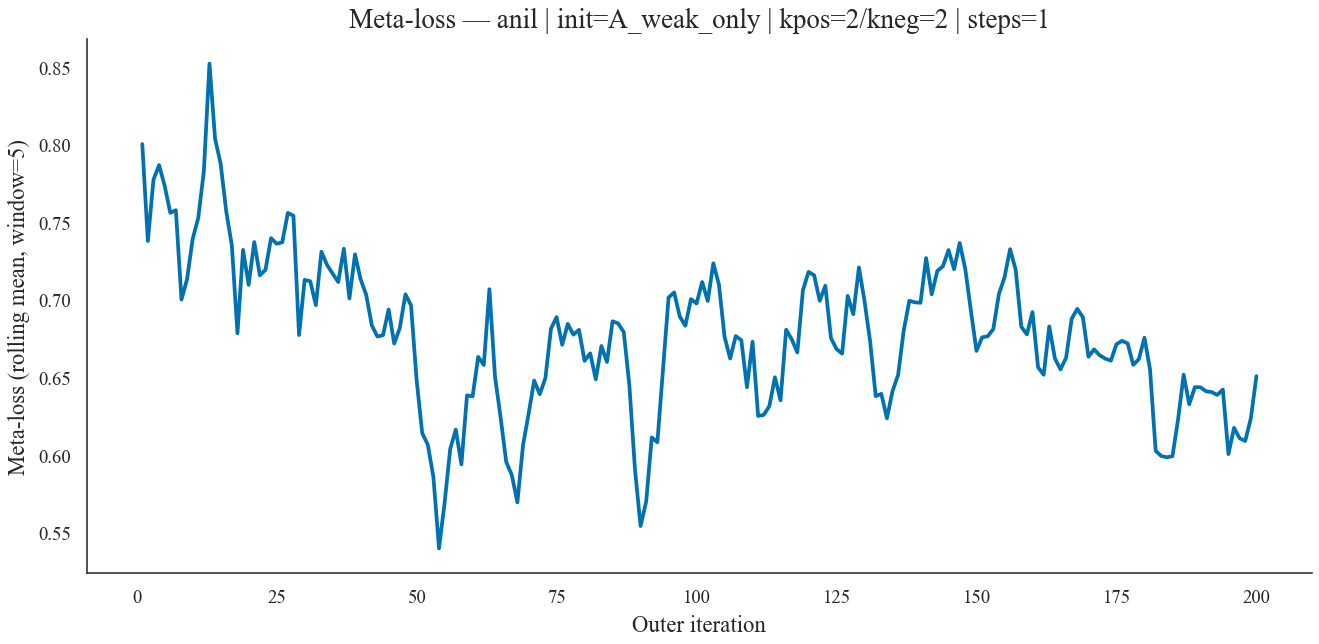

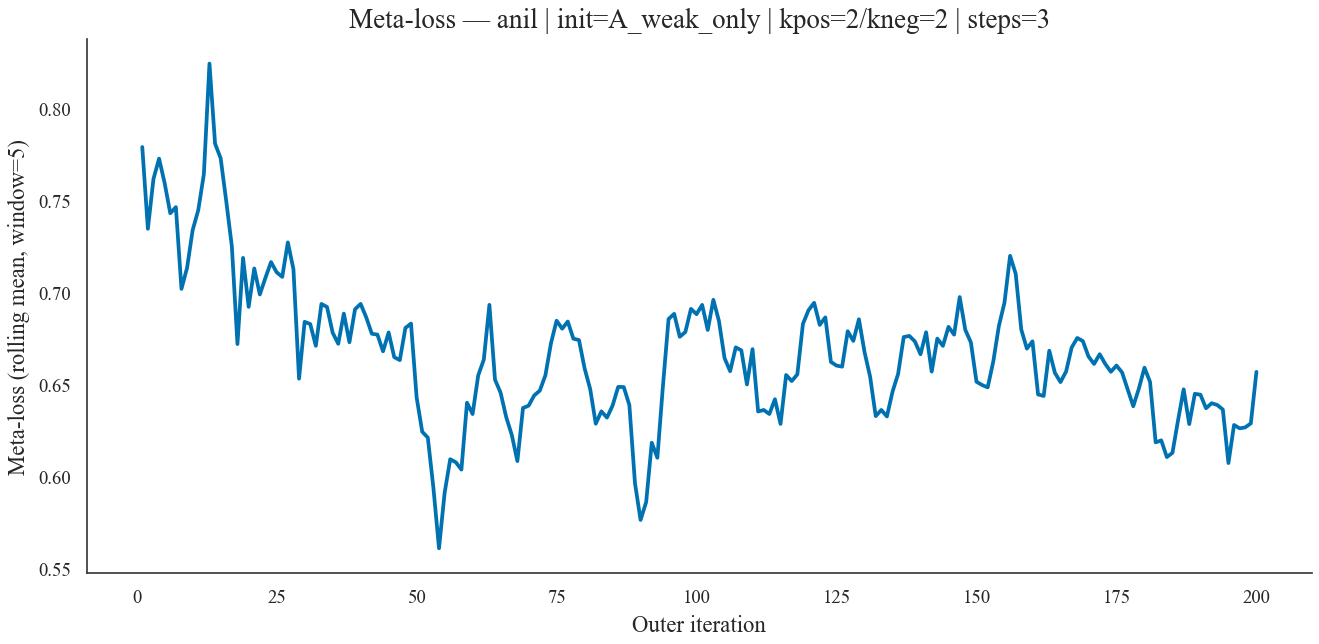

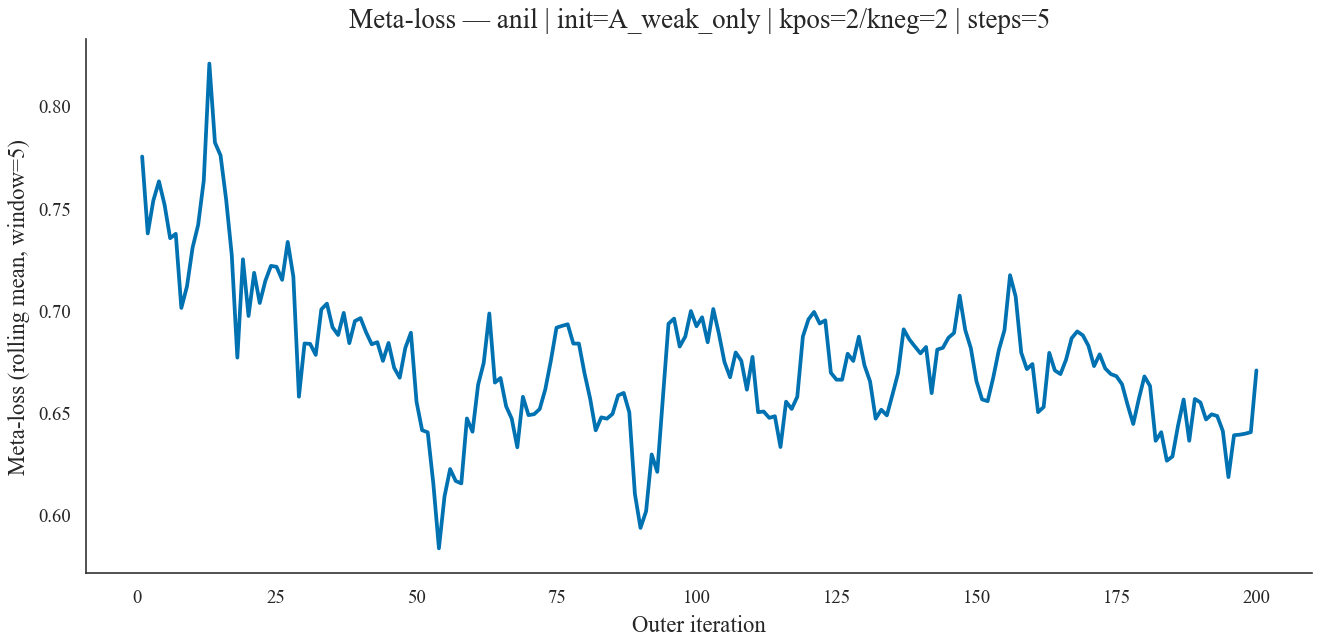

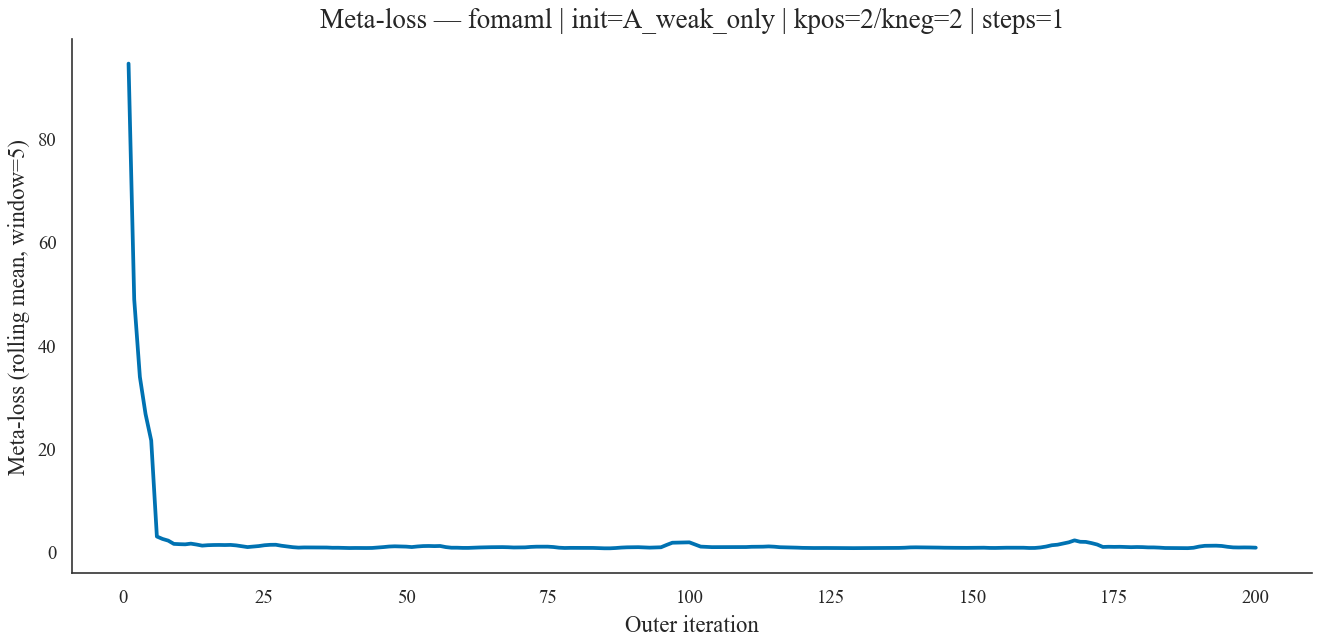

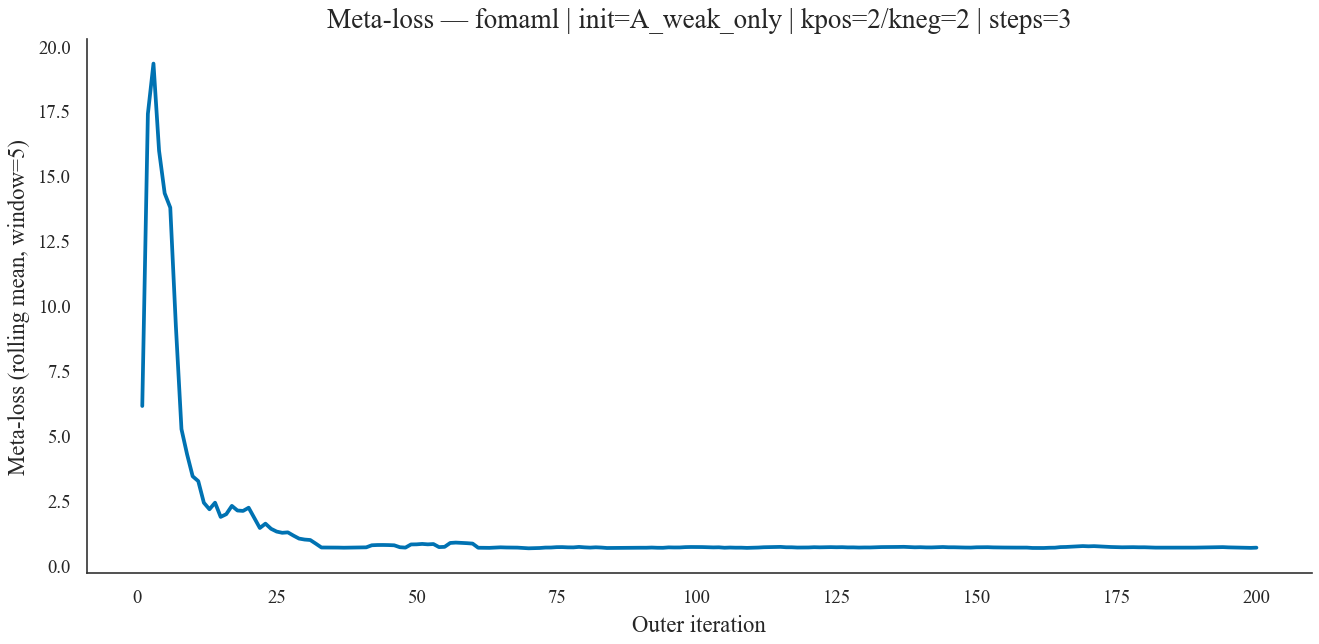

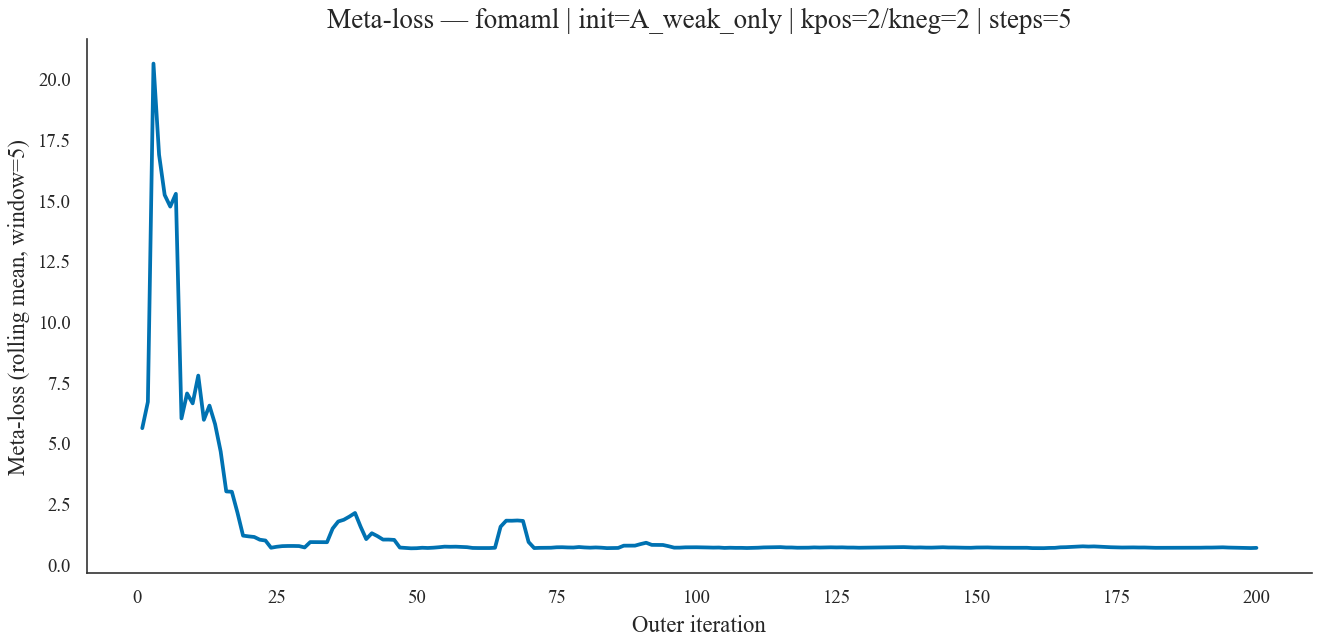

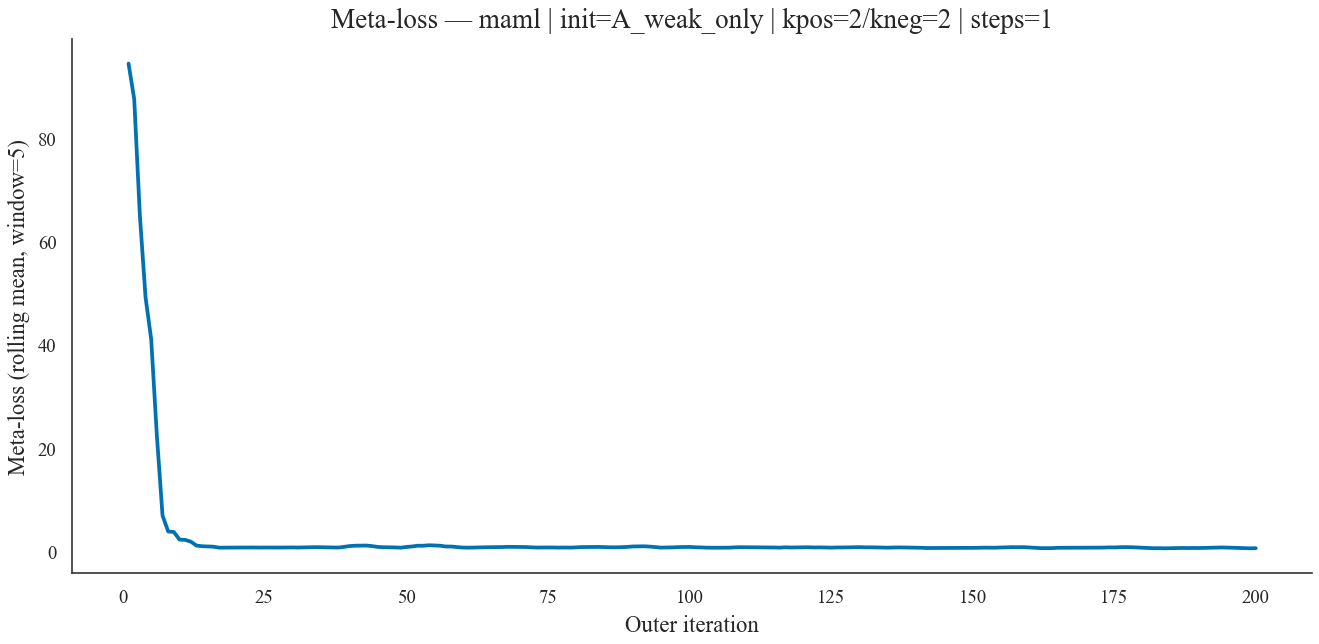

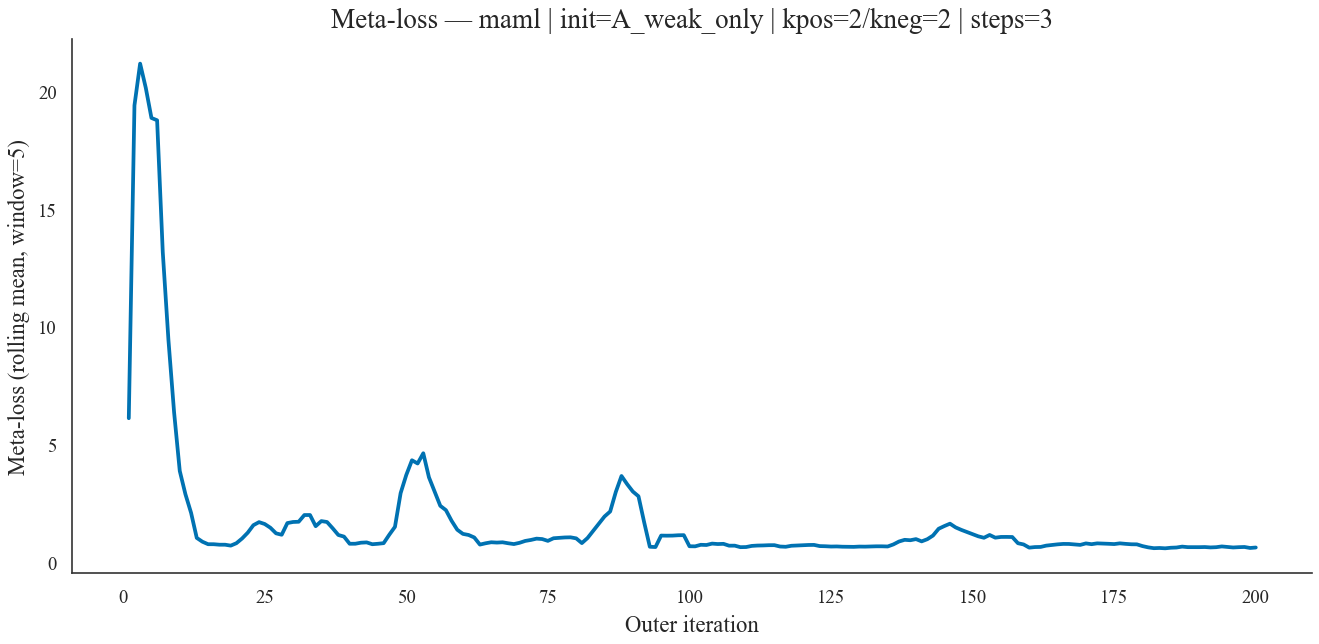

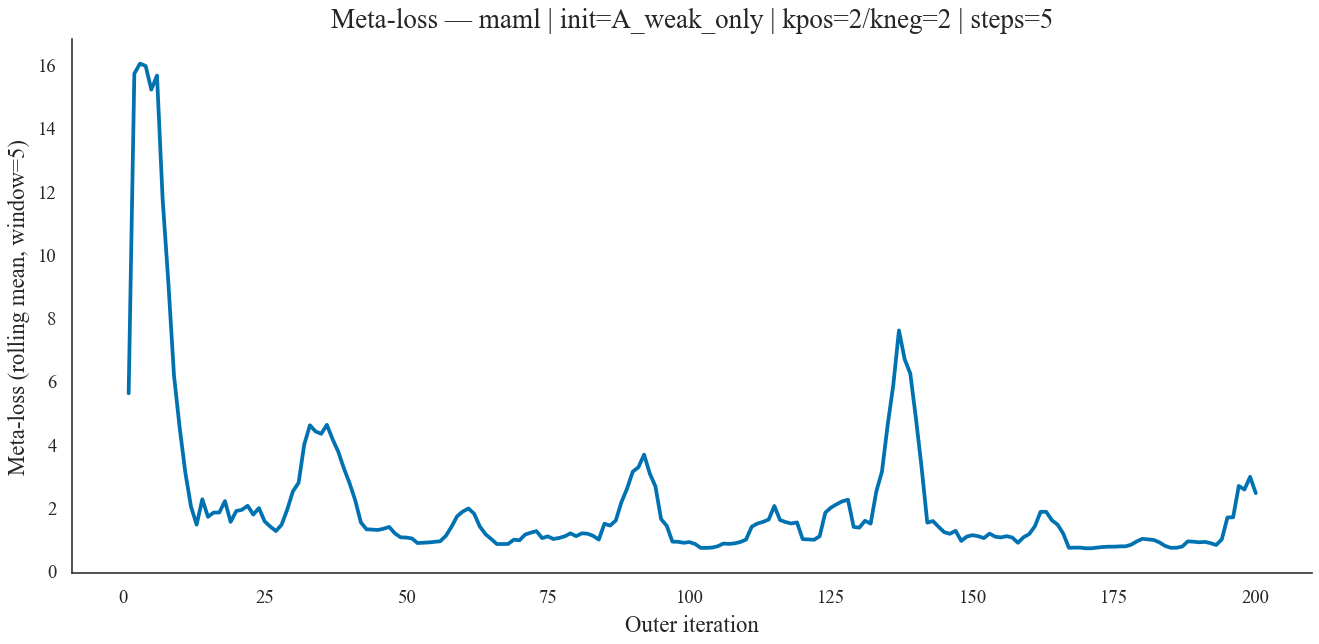

In [17]:
def _load_history(experiment_id: str) -> pd.DataFrame:
    p = EXPERIMENT_ROOT / experiment_id / "history.csv"
    if not p.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(p)
    except Exception:
        return pd.DataFrame()


METHODS_WITH_HISTORY = ("anil", "fomaml", "maml")
training_subset = filtered_df[filtered_df["method"].isin(METHODS_WITH_HISTORY)] if not filtered_df.empty else filtered_df

if training_subset.empty:
    print("No adaptive-method experiments in current filter.")
else:
    for _, row in training_subset.iterrows():
        exp_id = row["experiment_id"] if "experiment_id" in row else None
        history = _load_history(exp_id) if exp_id else pd.DataFrame()
        if history.empty:
            continue
        title = f"Meta-loss — {row.get('method','?')} | init={row.get('init_name','?')} | kpos={row.get('n_support_pos','?')}/kneg={row.get('n_support_neg','?')} | steps={row.get('inner_steps','?')}"
        plot_meta_training_curve(history, title=title)


## Collapse & Prediction-Distribution Diagnostic

Flags experiments whose per-episode predictions have collapsed onto a
single class (stdev near zero or extreme mean). This is a **label-free**
diagnostic — a collapsed model cannot produce useful rankings regardless
of the eventual gold-label scores.

,collapsed,pred_std,pred_mean,frac_near_zero,frac_near_one
method,,,,,
anil,0.0,0.102,0.503,0.000,0.001
finetune,0.9,0.028,0.480,0.506,0.446
fomaml,1.0,0.002,0.557,0.033,0.000
maml,0.7,0.011,0.515,0.131,0.132
zero_shot,0.0,0.138,0.132,0.464,0.000


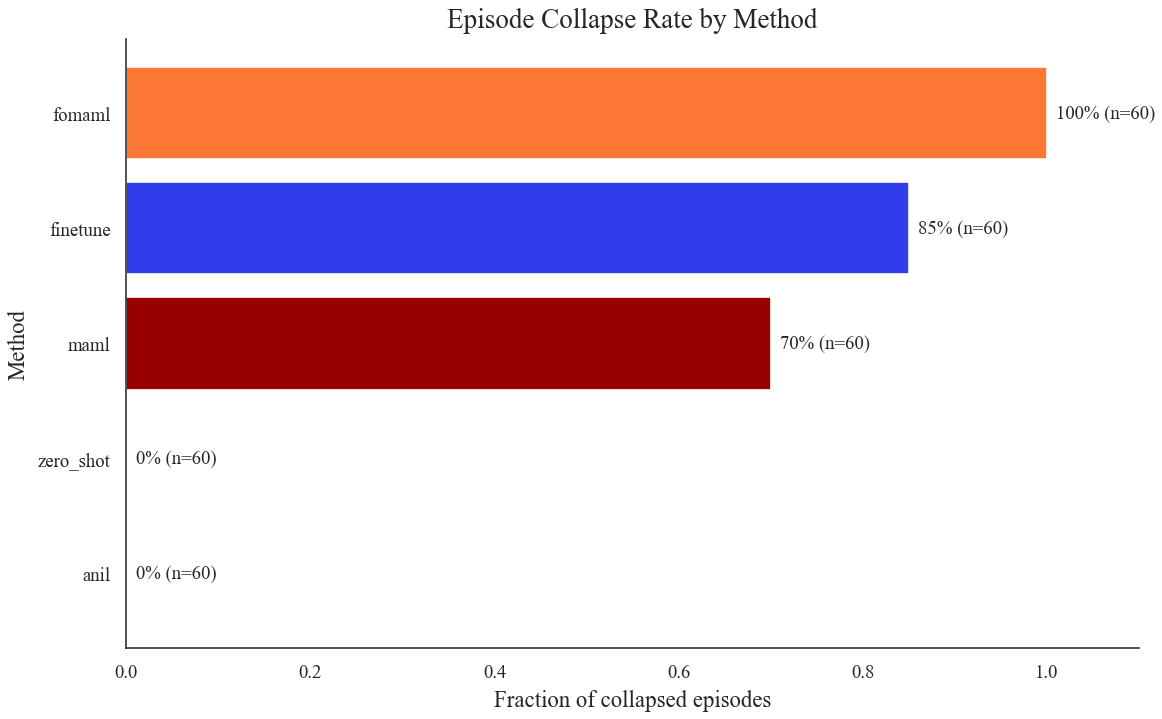

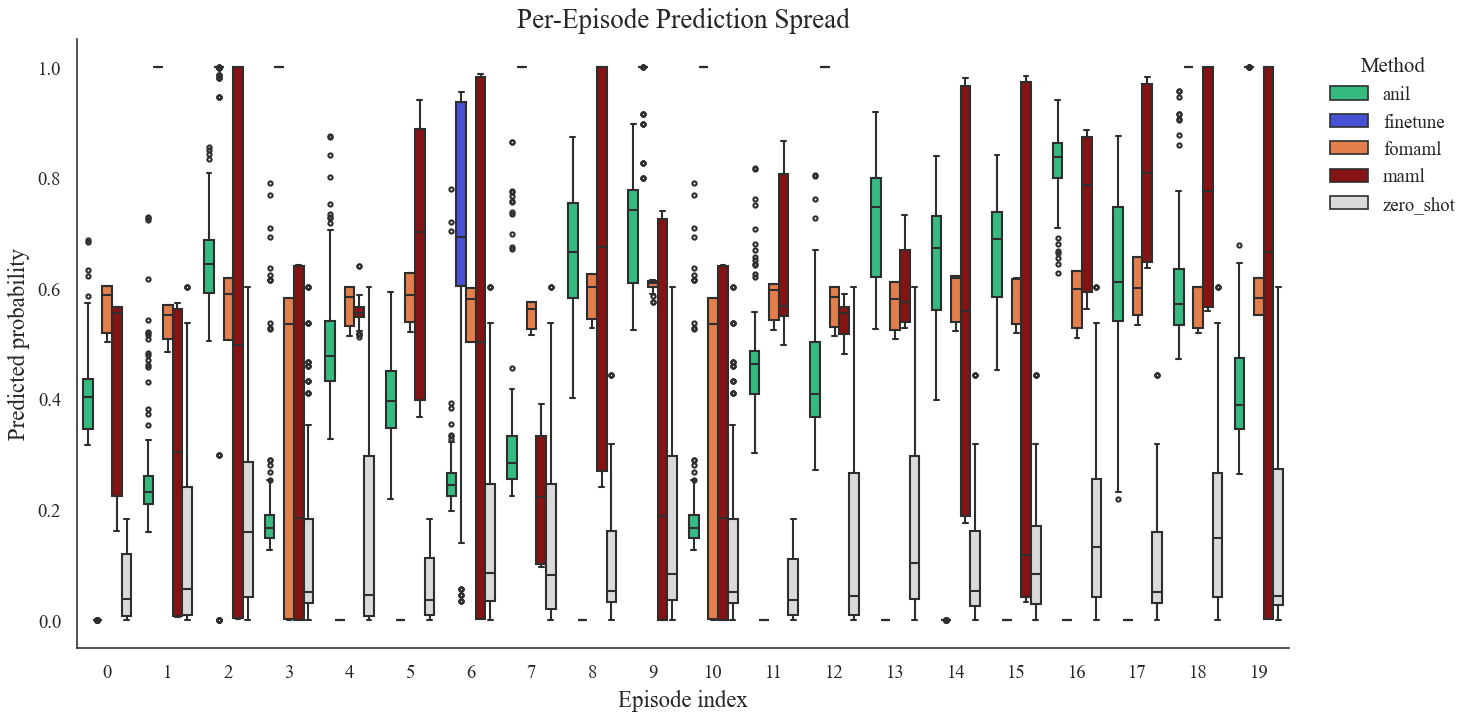

In [18]:
def _load_prediction_stats(experiment_id: str) -> pd.DataFrame:
    p = EXPERIMENT_ROOT / experiment_id / "prediction_stats.csv"
    if not p.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(p)
    except Exception:
        return pd.DataFrame()


def _load_predictions(experiment_id: str) -> pd.DataFrame:
    p = EXPERIMENT_ROOT / experiment_id / "predictions.csv"
    if not p.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(p)
    except Exception:
        return pd.DataFrame()


collapse_records = []
preds_records = []
for _, row in filtered_df.iterrows():
    exp_id = row.get("experiment_id")
    if not exp_id:
        continue

    stats = _load_prediction_stats(exp_id)
    if not stats.empty:
        stats = stats.copy()
        stats["experiment_id"] = exp_id
        stats["method"] = row.get("method")
        stats["init_name"] = row.get("init_name")
        stats["n_support_pos"] = row.get("n_support_pos")
        stats["n_support_neg"] = row.get("n_support_neg")
        stats["inner_steps"] = row.get("inner_steps")
        collapse_records.append(stats)

    preds = _load_predictions(exp_id)
    if not preds.empty and "y_prob" in preds.columns:
        preds = preds.copy()
        if "method" not in preds.columns or preds["method"].isna().all():
            preds["method"] = row.get("method")
        preds["experiment_id"] = exp_id
        preds_records.append(preds)

if collapse_records:
    collapse_df = pd.concat(collapse_records, ignore_index=True)
    # plot_collapse_rate uses method_col + prob_std_col (not group_by)
    plot_collapse_rate(
        collapse_df,
        method_col="method",
        prob_mean_col="pred_mean",
        prob_std_col="pred_std",
    )
    display(
        collapse_df
        .groupby("method")[["collapsed", "pred_std", "pred_mean",
                            "frac_near_zero", "frac_near_one"]]
        .mean()
        .round(3)
    )
else:
    print("No prediction_stats.csv files found. Re-run Stage 2 with the refactored code to emit them.")

if preds_records:
    all_preds = pd.concat(preds_records, ignore_index=True)
    # plot_episode_prediction_stats needs a long-form predictions frame with y_prob
    plot_episode_prediction_stats(
        all_preds,
        method_col="method",
        episode_col="episode_idx",
        prob_col="y_prob",
    )
else:
    print("No predictions.csv files found; skipping per-episode probability boxplot.")


## Embedding Projections

2-D projections (PCA / t-SNE) of the penultimate-layer representation for a
representative target episode. The panels compare the **zero-shot** Stage 1
representation against the **adapted** representation for each method.

These projections are **unsupervised with respect to gold labels**: they
visualise the *model's* representation of query contracts regardless of
how we later score them.

In [19]:
import torch
from master_thesis.explainability import (
    extract_mlp_embeddings,
    compute_2d_projection,
    compute_embedding_shift,
)
from master_thesis.mlp import TabularMLP
import joblib

try:
    from master_thesis.stage2 import build_stage2_model_from_config, load_stage1_model_weights
except ImportError:
    build_stage2_model_from_config = None

EMBED_METHOD = "pca"  # switch to "tsne" if the query set is large enough

# Pick one representative experiment (first adaptive method in filter).
ad_subset = filtered_df[filtered_df["method"].isin(("anil", "fomaml", "maml", "finetune"))] if not filtered_df.empty else filtered_df
if ad_subset.empty:
    print("No adaptive experiment in filter.")
else:
    ref = ad_subset.iloc[0]
    exp_id = ref["experiment_id"]
    exp_dir = EXPERIMENT_ROOT / exp_id
    cfg_path = exp_dir / "resolved_config.yaml"
    preds_path = exp_dir / "predictions.csv"
    if not (cfg_path.exists() and preds_path.exists()):
        print(f"Missing artifacts for {exp_id}; skipping embedding projection.")
    else:
        import yaml
        cfg = yaml.safe_load(open(cfg_path))
        preds = pd.read_csv(preds_path)
        first_episode_mask = preds["episode_idx"] == preds["episode_idx"].min()
        ep_preds = preds[first_episode_mask]
        print(f"Projecting embeddings for experiment: {exp_id}")
        print(f"Episode size: {len(ep_preds)} rows; y_prob std={ep_preds['y_prob'].std():.4f}")
        # Note: actual embedding extraction requires reloading the model + preprocessor +
        # the corresponding target-episode features. Users running this notebook after
        # a successful Stage 2 run can extend this cell to call
        # `extract_mlp_embeddings(model, X_query, layer='penultimate')`
        # and pass the result to `compute_2d_projection(...)` + `plot_department_embedding_projection(...)`.


Projecting embeddings for experiment: stage2__init-A_weak_only__method-anil__kpos-2__kneg-2__steps-1__target-Logistics
Episode size: 29 rows; y_prob std=0.1106


## SHAP Explainability

Feature attributions on the target-episode query set. Computed with
`run_pre_post_shap_pipeline` from `master_thesis.explainability`, which
compares the **pretrained Stage 1 model** (no adaptation) against an
**adapted model** from a Stage 2 experiment.

The attributions use only features — no gold labels — so they are safe to
inspect before any gold-label analysis.

In [20]:
from master_thesis.explainability import (
    build_feature_view_map,
    ShapResult,
    run_pre_post_shap_pipeline,
    aggregate_shap_by_view,
    compute_shap_delta,
    shap_feature_ranking,
)

# Users should plug in the actual (model_pre, model_post, X_background, X_explain, feature_names)
# below. The cell is scaffolded so the dashboard doesn't fail when those artifacts
# have not yet been produced.
print("SHAP section ready. Populate the variables below to produce plots:")
print("  shap_pre, shap_post = run_pre_post_shap_pipeline(model_pre, model_post, X_bg, X_ex, feature_names)")
print("  plot_shap_summary_bar(shap_post.mean_abs(), title='Top features — adapted model')")
print("  plot_view_level_shap_importance(aggregate_shap_by_view(shap_post, build_feature_view_map(feature_names)))")
print("  plot_shap_delta_importance(compute_shap_delta(shap_pre, shap_post))")


SHAP section ready. Populate the variables below to produce plots:
  shap_pre, shap_post = run_pre_post_shap_pipeline(model_pre, model_post, X_bg, X_ex, feature_names)
  plot_shap_summary_bar(shap_post.mean_abs(), title='Top features — adapted model')
  plot_view_level_shap_importance(aggregate_shap_by_view(shap_post, build_feature_view_map(feature_names)))
  plot_shap_delta_importance(compute_shap_delta(shap_pre, shap_post))


---
## Thesis Benchmark — Main Results

The cells below produce the final tables and plots used in the thesis.
Re-run after `bash experiments/run_thesis_benchmark.sh` to incorporate LR-sweep results.


In [ ]:
# ── Thesis benchmark configuration ─────────────────────────────────────
THESIS_INIT    = "A_weak_only"
THESIS_DEPT    = "Logistics"
THESIS_K       = (2, 2)            # (n_support_pos, n_support_neg)
THESIS_STEPS   = [1, 3, 5]
THESIS_LRS     = [0.001, 0.005, 0.01]
THESIS_METHODS = ["zero_shot", "finetune", "anil", "fomaml", "maml"]

# Filter summary to thesis scope
thesis_df = summary_df.copy()
if "target_department" in thesis_df.columns:
    thesis_df = thesis_df[thesis_df["target_department"] == THESIS_DEPT]
if "init_name" in thesis_df.columns:
    thesis_df = thesis_df[thesis_df["init_name"] == THESIS_INIT]
if "n_support_pos" in thesis_df.columns:
    thesis_df = thesis_df[thesis_df["n_support_pos"] == THESIS_K[0]]
if "n_support_neg" in thesis_df.columns:
    thesis_df = thesis_df[thesis_df["n_support_neg"] == THESIS_K[1]]
if "method" in thesis_df.columns:
    thesis_df = thesis_df[thesis_df["method"].isin(THESIS_METHODS)]

print(f"Thesis scope: {len(thesis_df)} experiments")
print("Methods:", thesis_df["method"].unique().tolist() if "method" in thesis_df.columns else "N/A")
if "inner_lr" in thesis_df.columns:
    print("LRs:   ", sorted(thesis_df["inner_lr"].dropna().unique().tolist()))
display(thesis_df[[c for c in ["method", "inner_steps", "inner_lr",
                                "auroc_mean", "auroc_std", "ndcg_at_10_mean",
                                "log_loss_mean", "ece_mean", "collapse_rate",
                                "experiment_id"] if c in thesis_df.columns]].sort_values(
    [c for c in ["method", "inner_steps"] if c in thesis_df.columns]
).reset_index(drop=True))


### Table A — Main Benchmark Results

Best configuration per method (highest AUROC).  Metrics are mean ± std across 20 evaluation episodes.


In [ ]:
# Table A: best config per method
_auroc_col = "auroc_mean" if "auroc_mean" in thesis_df.columns else "auroc"

if not thesis_df.empty and "method" in thesis_df.columns:
    _best_idx = thesis_df.groupby("method")[_auroc_col].idxmax()
    table_a = thesis_df.loc[_best_idx].copy()

    _show_cols = [c for c in [
        "method", "inner_steps", "inner_lr",
        "auroc_mean", "auroc_std",
        "ndcg_at_10_mean", "ndcg_at_10_std",
        "log_loss_mean", "log_loss_std",
        "ece_mean", "ece_std",
        "collapse_rate",
    ] if c in table_a.columns]
    table_a_display = table_a[_show_cols].sort_values("auroc_mean", ascending=False).reset_index(drop=True)

    # Format display: round to 3 dp
    for _c in table_a_display.select_dtypes(include="number").columns:
        table_a_display[_c] = table_a_display[_c].round(3)

    print("Table A — Best configuration per method")
    display(table_a_display)

    # Save
    _save = REPORTS_DIR / "table_A_main_benchmark.csv"
    table_a_display.to_csv(_save, index=False)
    print(f"Saved: {_save}")
else:
    print("thesis_df is empty — run the benchmark first.")


### Table B — Inner-Step Sensitivity

All method × steps combinations (best LR per combination).


In [ ]:
# Table B: step sensitivity
if not thesis_df.empty and "method" in thesis_df.columns and "inner_steps" in thesis_df.columns:
    if "inner_lr" in thesis_df.columns:
        _best_b = thesis_df.groupby(["method", "inner_steps"])[_auroc_col].idxmax()
        table_b = thesis_df.loc[_best_b].copy()
    else:
        table_b = thesis_df.copy()

    _show_b = [c for c in ["method", "inner_steps", "inner_lr",
                            "auroc_mean", "ndcg_at_10_mean", "log_loss_mean",
                            "ece_mean", "collapse_rate"] if c in table_b.columns]
    table_b_display = table_b[_show_b].sort_values(
        ["method", "inner_steps"]).reset_index(drop=True)
    for _c in table_b_display.select_dtypes(include="number").columns:
        table_b_display[_c] = table_b_display[_c].round(3)

    print("Table B — Inner-step sensitivity (best LR per combination)")
    display(table_b_display)
    _save = REPORTS_DIR / "table_B_step_sensitivity.csv"
    table_b_display.to_csv(_save, index=False)
    print(f"Saved: {_save}")


### Table C — LR Sensitivity (Adaptive Methods)

All method × inner_lr combinations (steps=5, i.e. best step for adaptive methods).


In [ ]:
# Table C: LR sensitivity
if not thesis_df.empty and "inner_lr" in thesis_df.columns:
    _adaptive = ["anil", "fomaml", "maml"]
    _steps_sel = 5 if 5 in thesis_df.get("inner_steps", pd.Series()).values else \
                 thesis_df["inner_steps"].max() if "inner_steps" in thesis_df.columns else None

    table_c = thesis_df[
        thesis_df["method"].isin(_adaptive)
        & (thesis_df["inner_steps"] == _steps_sel if _steps_sel is not None else True)
    ].copy() if "method" in thesis_df.columns else thesis_df.copy()

    _show_c = [c for c in ["method", "inner_steps", "inner_lr",
                            "auroc_mean", "ndcg_at_10_mean", "collapse_rate"] if c in table_c.columns]
    table_c_display = table_c[_show_c].sort_values(
        [c for c in ["method", "inner_lr"] if c in table_c.columns]).reset_index(drop=True)
    for _c in table_c_display.select_dtypes(include="number").columns:
        table_c_display[_c] = table_c_display[_c].round(3)

    print(f"Table C — LR sensitivity at steps={_steps_sel}")
    display(table_c_display)
    _save = REPORTS_DIR / "table_C_lr_sensitivity.csv"
    table_c_display.to_csv(_save, index=False)
    print(f"Saved: {_save}")
else:
    print("No inner_lr column — run thesis_adaptive_lr_sweep first.")


### Figure — Method Comparison Bar Chart

Four-panel grouped bar chart comparing best configurations across AUROC, NDCG@10, Log-Loss, and ECE.  Error bars = ±1 std across episodes.


In [ ]:
# Method comparison bars
if not thesis_df.empty and "method" in thesis_df.columns:
    # Zero-shot reference row (steps irrelevant for zero_shot)
    _zs = thesis_df[thesis_df["method"] == "zero_shot"] if "method" in thesis_df.columns else pd.DataFrame()
    _zs_ref = _zs.iloc[0] if not _zs.empty else None

    fig_bars, axes_bars = plot_method_comparison_bars(
        thesis_df,
        metrics=["auroc", "ndcg_at_10", "log_loss", "ece"],
        zero_shot_ref_row=_zs_ref,
        title=f"Stage 2 Method Comparison — {THESIS_DEPT} (k={THESIS_K[0]}/{THESIS_K[1]})",
        save_path=str(REPORTS_DIR / "fig_method_comparison_bars.png"),
    )
    import matplotlib.pyplot as plt
    plt.show()
    print("Saved: ", REPORTS_DIR / "fig_method_comparison_bars.png")


### Figure — LR Sweep: AUROC vs. Inner LR

Line plots of AUROC as a function of inner learning rate for ANIL, FOMAML, and MAML.  Each line represents one inner-step count.  Dashed line = zero-shot reference AUROC.


In [ ]:
# LR sweep: AUROC vs. inner_lr
if "inner_lr" in thesis_df.columns and not thesis_df.empty:
    _zs_auroc = None
    if "method" in thesis_df.columns:
        _zs_rows = thesis_df[thesis_df["method"] == "zero_shot"]
        if not _zs_rows.empty and "auroc_mean" in _zs_rows.columns:
            _zs_auroc = float(_zs_rows["auroc_mean"].iloc[0])

    import matplotlib.pyplot as plt
    for _metric, _label in [("auroc", "AUROC"), ("ndcg_at_10", "NDCG@10")]:
        fig_lr, axes_lr = plot_lr_sweep_comparison(
            thesis_df,
            methods=["anil", "fomaml", "maml"],
            metric=_metric,
            metric_label=_label,
            zero_shot_ref=_zs_auroc if _metric == "auroc" else None,
            title=f"{_label} vs. Inner LR — {THESIS_DEPT}",
            save_path=str(REPORTS_DIR / f"fig_lr_sweep_{_metric}.png"),
        )
        plt.show()
        print(f"Saved: ", REPORTS_DIR / f"fig_lr_sweep_{_metric}.png")
else:
    print("No inner_lr column in thesis_df — run thesis_adaptive_lr_sweep first.")


### Figure — Collapse Rate Heatmaps (FOMAML & MAML)

Fraction of evaluation episodes where predictions collapsed to a near-constant value, shown as a heatmap across inner_steps × inner_lr.


In [ ]:
# Collapse rate heatmaps
import matplotlib.pyplot as plt
if "inner_lr" in thesis_df.columns and "collapse_rate" in thesis_df.columns:
    for _m in ["fomaml", "maml"]:
        fig_ht, ax_ht = plot_collapse_rate_heatmap(
            thesis_df,
            method=_m,
            save_path=str(REPORTS_DIR / f"fig_collapse_heatmap_{_m}.png"),
        )
        plt.show()
        print(f"Saved: ", REPORTS_DIR / f"fig_collapse_heatmap_{_m}.png")
else:
    print("inner_lr or collapse_rate missing — LR sweep data not yet available.")

# Also plot collapse rate vs. steps for ALL methods at their default LR
if "collapse_rate" in thesis_df.columns and "inner_steps" in thesis_df.columns:
    _cdf = thesis_df.copy()
    # Use best-LR row per (method, steps)
    if "inner_lr" in _cdf.columns:
        _idx = _cdf.groupby(["method", "inner_steps"])["auroc_mean"].idxmax()
        _cdf = _cdf.loc[_idx]
    fig_cr, ax_cr = plot_collapse_rate(_cdf)
    plt.show()


### Table D — Collapse Rate vs. LR (FOMAML & MAML)

Per-(method, steps, lr) collapse_rate.  Values < 0.1 indicate stable adaptation; values ≈ 1.0 indicate complete collapse.


In [ ]:
# Table D: collapse rates across LR sweep
if "inner_lr" in thesis_df.columns and "collapse_rate" in thesis_df.columns:
    _adaptive = ["anil", "fomaml", "maml"]
    table_d = thesis_df[
        thesis_df["method"].isin(_adaptive)
    ][[c for c in ["method", "inner_steps", "inner_lr", "collapse_rate",
                    "auroc_mean", "ndcg_at_10_mean"] if c in thesis_df.columns]].copy()
    for _c in table_d.select_dtypes(include="number").columns:
        table_d[_c] = table_d[_c].round(3)
    table_d = table_d.sort_values(
        [c for c in ["method", "inner_steps", "inner_lr"] if c in table_d.columns]
    ).reset_index(drop=True)
    print("Table D — Collapse rate across LR sweep")
    display(table_d)
    _save = REPORTS_DIR / "table_D_collapse_lr.csv"
    table_d.to_csv(_save, index=False)
    print(f"Saved: {_save}")
else:
    print("LR sweep data not yet available.")


### Table E — Stage 1 vs. Stage 2 Comparison

Zero-shot (Stage 1 pre-trained model applied directly) vs. best adaptive method.


In [ ]:
# Table E: Stage 1 (zero_shot) vs. Stage 2 best adaptive
if not thesis_df.empty and "method" in thesis_df.columns:
    _metric_cols = [c for c in [
        "auroc_mean", "auroc_std",
        "ndcg_at_10_mean", "ndcg_at_10_std",
        "log_loss_mean", "ece_mean", "collapse_rate",
    ] if c in thesis_df.columns]

    _zs_row = thesis_df[thesis_df["method"] == "zero_shot"]
    if not _zs_row.empty:
        _zs_row = _zs_row.iloc[[0]].copy()
        _zs_row["label"] = "Stage 1 (zero-shot)"

    _adapt_df = thesis_df[thesis_df["method"] != "zero_shot"]
    if not _adapt_df.empty and "auroc_mean" in _adapt_df.columns:
        _best_adapt_idx = _adapt_df["auroc_mean"].idxmax()
        _best_adapt = _adapt_df.loc[[_best_adapt_idx]].copy()
        _method_name = _best_adapt["method"].iloc[0] if "method" in _best_adapt.columns else "best"
        _best_adapt["label"] = f"Stage 2 best ({_method_name})"

        if not _zs_row.empty:
            table_e = pd.concat([_zs_row, _best_adapt], ignore_index=True)
            table_e_display = table_e[["label"] + _metric_cols]
            for _c in table_e_display.select_dtypes(include="number").columns:
                table_e_display[_c] = table_e_display[_c].round(3)
            print("Table E — Stage 1 vs. Stage 2")
            display(table_e_display)
            _save = REPORTS_DIR / "table_E_stage1_vs_stage2.csv"
            table_e_display.to_csv(_save, index=False)
            print(f"Saved: {_save}")
        else:
            print("No zero_shot row found in thesis_df.")
    else:
        print("No adaptive method results found.")
